# HV-AI-2025 — Complete Local Training & Inference Notebook

This notebook is arranged so the **training phases can be completed now**, while the separate hidden/test set can be added later.

### Phase 1
**Supervised ImageNet-pretrained ResNet-18 → animal classification**

### Phase 2
**SimCLR self-supervised pretraining on the unlabeled images → transfer the encoder → supervised fine-tuning on the labeled images**

### Saved artifacts
- `best_phase1_model.pt`
- `simclr_encoder.pt`
- `best_phase2_model.pt`
- `phase1_predictions.csv` *(created only after the test set is supplied)*
- `phase2_predictions.csv` *(created only after the test set is supplied)*
- `training_history.csv`
- `phase_comparison.csv`

**Important:** The test set is never used for training or validation. It is used only in the final inference section.

In [1]:
# CELL 1 — Imports, reproducibility, paths and configuration

import os
import random
import copy
import time
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# -------------------------
# Automatically locate the dataset
# -------------------------
CANDIDATE_ROOTS = [
    Path("./HV-AI-2025/HV-AI-2025"),  # your current VS Code layout
    Path("./HV-AI-2025"),
    Path("."),
]

DATA_ROOT = None
for candidate in CANDIDATE_ROOTS:
    if (candidate / "labeled_data" / "labeled_data.csv").exists():
        DATA_ROOT = candidate
        break

if DATA_ROOT is None:
    raise FileNotFoundError(
        "Could not find labeled_data/labeled_data.csv. "
        "Set DATA_ROOT manually in this cell."
    )

LABELED_ROOT = DATA_ROOT / "labeled_data"
LABELS_FILE = LABELED_ROOT / "labeled_data.csv"
LABELED_IMAGE_ROOT = LABELED_ROOT / "images"
UNLABELED_IMAGE_ROOT = DATA_ROOT / "unlabeled_data" / "images"

# The hidden test set is NOT currently present in your local folder.
# When provided, place it at DATA_ROOT/test_data/images or change this path.
TEST_IMAGE_ROOT = DATA_ROOT / "test_data" / "images"

OUTPUT_ROOT = Path("./hv_ai_outputs")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

# -------------------------
# Training configuration
# -------------------------
SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0
PIN_MEMORY = torch.cuda.is_available()

VAL_SIZE = 0.20

# Phase 1: supervised
PHASE1_EPOCHS = 20
PHASE1_LR = 3e-4
PHASE1_WEIGHT_DECAY = 1e-4
PHASE1_PATIENCE = 5

# Phase 2: SimCLR
SIMCLR_EPOCHS = 10
SIMCLR_LR = 3e-4
SIMCLR_WEIGHT_DECAY = 1e-4
SIMCLR_TEMPERATURE = 0.5
SIMCLR_PROJECTION_DIM = 128

# Phase 2 classifier fine-tuning
PHASE2_EPOCHS = 20
PHASE2_LR = 1e-4
PHASE2_WEIGHT_DECAY = 1e-4
PHASE2_PATIENCE = 5

# Keep this True when internet is available so ResNet-18 starts from ImageNet weights.
USE_IMAGENET_PRETRAINED = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("DATA_ROOT:", DATA_ROOT.resolve())
print("OUTPUT_ROOT:", OUTPUT_ROOT.resolve())
print("Labeled CSV:", LABELS_FILE.resolve())

Device: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
DATA_ROOT: C:\Users\srima\Desktop\HyperVerge\HV-AI-2025\HV-AI-2025
OUTPUT_ROOT: C:\Users\srima\Desktop\HyperVerge\hv_ai_outputs
Labeled CSV: C:\Users\srima\Desktop\HyperVerge\HV-AI-2025\HV-AI-2025\labeled_data\labeled_data.csv


In [2]:
# CELL 2 — Verify the exact dataset structure

def list_images(root):
    root = Path(root)
    if not root.exists():
        return []
    return sorted(
        p for p in root.rglob("*")
        if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS
    )

assert LABELS_FILE.exists(), f"Missing: {LABELS_FILE}"
assert LABELED_IMAGE_ROOT.exists(), f"Missing: {LABELED_IMAGE_ROOT}"
assert UNLABELED_IMAGE_ROOT.exists(), f"Missing: {UNLABELED_IMAGE_ROOT}"

labeled_files = list_images(LABELED_IMAGE_ROOT)
unlabeled_files = list_images(UNLABELED_IMAGE_ROOT)

test_files = list_images(TEST_IMAGE_ROOT) if TEST_IMAGE_ROOT.exists() else []

print("Labeled image files  :", len(labeled_files))
print("Unlabeled image files:", len(unlabeled_files))
print("Test image files     :", len(test_files))

if not test_files:
    print("\nNOTE: Test set is not present yet. That is OK.")
    print("Training/validation can be completed now.")
    print("When the test set arrives, put images in:")
    print(TEST_IMAGE_ROOT.resolve())

Labeled image files  : 779
Unlabeled image files: 14800
Test image files     : 0

NOTE: Test set is not present yet. That is OK.
Training/validation can be completed now.
When the test set arrives, put images in:
C:\Users\srima\Desktop\HyperVerge\HV-AI-2025\HV-AI-2025\test_data\images


## Phase 1 — Load, clean and split the labeled dataset

In [3]:
# CELL 3 — Load labeled CSV and match every CSV row to an image

labels_df = pd.read_csv(LABELS_FILE)
print("CSV shape:", labels_df.shape)
print("Columns:", list(labels_df.columns))
display(labels_df.head())

required_columns = {"img_name", "label"}
if not required_columns.issubset(labels_df.columns):
    raise ValueError(
        f"Expected columns {required_columns}, found {set(labels_df.columns)}"
    )

labels_df = labels_df[["img_name", "label"]].copy()
labels_df["img_name"] = labels_df["img_name"].astype(str).str.strip()
labels_df["label"] = labels_df["label"].astype(str).str.strip()

# Match by filename. Case-insensitive matching is used as a fallback.
image_index = {}
for p in labeled_files:
    image_index.setdefault(p.name, p)
    image_index.setdefault(p.name.lower(), p)

labels_df["image_path"] = labels_df["img_name"].map(image_index)
missing_mask = labels_df["image_path"].isna()
labels_df.loc[missing_mask, "image_path"] = labels_df.loc[missing_mask, "img_name"].str.lower().map(image_index)

missing_df = labels_df[labels_df["image_path"].isna()].copy()
matched_df = labels_df[labels_df["image_path"].notna()].copy()

print("CSV rows           :", len(labels_df))
print("Matched rows       :", len(matched_df))
print("Missing image rows :", len(missing_df))

if len(missing_df):
    print("\nFirst missing files:")
    display(missing_df.head(20))


def is_readable(path):
    try:
        with Image.open(path) as im:
            im.verify()
        return True
    except Exception:
        return False

readable_mask = matched_df["image_path"].map(is_readable)
corrupt_df = matched_df[~readable_mask].copy()
matched_df = matched_df[readable_mask].reset_index(drop=True)

print("Corrupt/unreadable :", len(corrupt_df))
print("Final usable rows  :", len(matched_df))

if len(matched_df) == 0:
    raise RuntimeError("No usable labeled images were found.")

CLASS_NAMES = sorted(matched_df["label"].unique().tolist())
NUM_CLASSES = len(CLASS_NAMES)
label_to_idx = {name: idx for idx, name in enumerate(CLASS_NAMES)}
idx_to_label = {idx: name for name, idx in label_to_idx.items()}
matched_df["label_idx"] = matched_df["label"].map(label_to_idx)

print("\nClasses:", CLASS_NAMES)
print("Number of classes:", NUM_CLASSES)
print("\nClass distribution:")
display(matched_df["label"].value_counts().sort_index())

if NUM_CLASSES != 10:
    print("WARNING: assignment is expected to have 10 classes; found", NUM_CLASSES)

CSV shape: (779, 2)
Columns: ['img_name', 'label']


,img_name,label
0,OIP--khXa4p9B3QV8JmsHX29hgHaEK.jpeg,cane
1,OIP--winA9MguCMZn6fdverPlwHaEK.jpeg,cane
2,OIP-0M8AAbNON2zvyCEB2WEhLQHaE8.jpeg,cane
3,OIP-16Mqc38MKBFr4a33cb_dFwHaGO.jpeg,cane
4,OIP-2sIPje3EMq9bP0vV2OGfmwHaEG.jpeg,cane


CSV rows           : 779
Matched rows       : 779
Missing image rows : 0
Corrupt/unreadable : 0
Final usable rows  : 779

Classes: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']
Number of classes: 10

Class distribution:


label
cane          145
cavallo        78
elefante       43
farfalla       63
gallina        92
gatto          50
mucca          55
pecora         54
ragno         144
scoiattolo     55
Name: count, dtype: int64

In [4]:
# CELL 4 — Stratified train/validation split

train_df, val_df = train_test_split(
    matched_df,
    test_size=VAL_SIZE,
    random_state=SEED,
    stratify=matched_df["label_idx"],
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Training images  :", len(train_df))
print("Validation images:", len(val_df))

distribution = pd.DataFrame({
    "train": train_df["label"].value_counts(),
    "validation": val_df["label"].value_counts(),
}).fillna(0).astype(int).sort_index()

display(distribution)

Training images  : 623
Validation images: 156


,train,validation
label,,
cane,116,29
cavallo,62,16
elefante,35,8
farfalla,50,13
gallina,74,18
gatto,40,10
mucca,44,11
pecora,43,11
ragno,115,29


In [5]:
# CELL 5 — Image transforms, Dataset and DataLoaders

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.70, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.20, contrast=0.20, saturation=0.20, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class AnimalDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        with Image.open(row["image_path"]) as im:
            image = im.convert("RGB")
        image = self.transform(image)
        return image, int(row["label_idx"])

# Weighted sampling helps the smaller animal classes contribute more uniformly.
class_counts = train_df["label_idx"].value_counts().sort_index()
weights_per_class = 1.0 / class_counts.values
sample_weights = train_df["label_idx"].map(
    {i: float(weights_per_class[i]) for i in range(NUM_CLASSES)}
).values
sampler = WeightedRandomSampler(
    weights=torch.as_tensor(sample_weights, dtype=torch.double),
    num_samples=len(sample_weights),
    replacement=True,
)

train_dataset = AnimalDataset(train_df, train_transform)
val_dataset = AnimalDataset(val_df, eval_transform)

loader_kwargs = dict(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
if NUM_WORKERS > 0:
    loader_kwargs["persistent_workers"] = True

train_loader = DataLoader(train_dataset, sampler=sampler, **loader_kwargs)
val_loader = DataLoader(val_dataset, shuffle=False, **loader_kwargs)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))

Train batches: 20
Val batches  : 5


## Phase 1 — Supervised ResNet-18 training

In [6]:
# CELL 6 — Model, loss, metrics, checkpoint helpers and Phase 1 training

def get_resnet18(pretrained=True):
    if pretrained:
        try:
            return models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        except Exception as e:
            print("Could not load ImageNet weights. Falling back to random initialization.")
            print("Reason:", e)
    return models.resnet18(weights=None)


def build_classifier(num_classes, pretrained=True):
    model = get_resnet18(pretrained=pretrained)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model


def make_class_weights(df):
    counts = df["label_idx"].value_counts().reindex(range(NUM_CLASSES)).fillna(0)
    w = len(df) / (NUM_CLASSES * counts.replace(0, 1))
    return torch.tensor(w.values, dtype=torch.float32, device=DEVICE)

class_weights = make_class_weights(train_df)
criterion1 = nn.CrossEntropyLoss(weight=class_weights)


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    running_loss = 0.0
    all_targets, all_preds = [], []

    for images, targets in loader:
        images = images.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            logits = model(images)
            loss = criterion(logits, targets)
            if is_train:
                loss.backward()
                optimizer.step()

        running_loss += loss.item() * images.size(0)
        all_targets.extend(targets.detach().cpu().numpy())
        all_preds.extend(logits.argmax(dim=1).detach().cpu().numpy())

    loss_value = running_loss / len(loader.dataset)
    acc_value = accuracy_score(all_targets, all_preds)
    return loss_value, acc_value


def save_checkpoint(path, model, optimizer=None, scheduler=None, **extra):
    checkpoint = {
        "model_state_dict": model.state_dict(),
        "class_names": CLASS_NAMES,
        "label_to_idx": label_to_idx,
        "img_size": IMG_SIZE,
        "imagenet_mean": IMAGENET_MEAN,
        "imagenet_std": IMAGENET_STD,
        **extra,
    }
    if optimizer is not None:
        checkpoint["optimizer_state_dict"] = optimizer.state_dict()
    if scheduler is not None:
        checkpoint["scheduler_state_dict"] = scheduler.state_dict()
    torch.save(checkpoint, path)

phase1_model = build_classifier(NUM_CLASSES, pretrained=USE_IMAGENET_PRETRAINED).to(DEVICE)
optimizer1 = torch.optim.AdamW(
    phase1_model.parameters(),
    lr=PHASE1_LR,
    weight_decay=PHASE1_WEIGHT_DECAY,
)
scheduler1 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer1, mode="max", factor=0.5, patience=2
)

PHASE1_PATH = OUTPUT_ROOT / "best_phase1_model.pt"
phase1_history = []
best_phase1_acc = -1.0
best_phase1_state = None
bad_epochs = 0

for epoch in range(1, PHASE1_EPOCHS + 1):
    start = time.time()
    train_loss, train_acc = run_epoch(phase1_model, train_loader, criterion1, optimizer1)
    val_loss, val_acc = run_epoch(phase1_model, val_loader, criterion1)
    scheduler1.step(val_acc)

    phase1_history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "val_loss": val_loss,
        "val_accuracy": val_acc,
        "lr": optimizer1.param_groups[0]["lr"],
    })

    print(
        f"Epoch [{epoch:02d}/{PHASE1_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
        f"Time: {time.time()-start:.1f}s"
    )

    if val_acc > best_phase1_acc:
        best_phase1_acc = val_acc
        best_phase1_state = copy.deepcopy(phase1_model.state_dict())
        save_checkpoint(
            PHASE1_PATH,
            phase1_model,
            optimizer1,
            scheduler1,
            phase="phase1",
            best_val_accuracy=best_phase1_acc,
        )
        bad_epochs = 0
        print(f"  ✓ Saved best Phase 1 model: {best_phase1_acc:.4f}")
    else:
        bad_epochs += 1

    if bad_epochs >= PHASE1_PATIENCE:
        print("Early stopping Phase 1.")
        break

phase1_model.load_state_dict(best_phase1_state)
pd.DataFrame(phase1_history).to_csv(OUTPUT_ROOT / "phase1_training_history.csv", index=False)

print("\nBest Phase 1 validation accuracy:", round(best_phase1_acc, 4))
print("Saved model:", PHASE1_PATH.resolve())

Epoch [01/20] | Train Loss: 0.9101 | Train Acc: 0.6693 | Val Loss: 0.9845 | Val Acc: 0.7179 | Time: 4.2s
  ✓ Saved best Phase 1 model: 0.7179
Epoch [02/20] | Train Loss: 0.2624 | Train Acc: 0.9117 | Val Loss: 0.8174 | Val Acc: 0.7885 | Time: 8.4s
  ✓ Saved best Phase 1 model: 0.7885
Epoch [03/20] | Train Loss: 0.1742 | Train Acc: 0.9454 | Val Loss: 0.8533 | Val Acc: 0.7436 | Time: 5.5s
Epoch [04/20] | Train Loss: 0.1272 | Train Acc: 0.9631 | Val Loss: 0.7740 | Val Acc: 0.7885 | Time: 3.4s
Epoch [05/20] | Train Loss: 0.0833 | Train Acc: 0.9775 | Val Loss: 1.0543 | Val Acc: 0.7436 | Time: 3.4s
Epoch [06/20] | Train Loss: 0.0847 | Train Acc: 0.9695 | Val Loss: 0.7644 | Val Acc: 0.7756 | Time: 3.7s
Epoch [07/20] | Train Loss: 0.0370 | Train Acc: 0.9872 | Val Loss: 0.6736 | Val Acc: 0.8205 | Time: 4.0s
  ✓ Saved best Phase 1 model: 0.8205
Epoch [08/20] | Train Loss: 0.0251 | Train Acc: 0.9920 | Val Loss: 0.5882 | Val Acc: 0.8333 | Time: 3.7s
  ✓ Saved best Phase 1 model: 0.8333
Epoch [09/20

PHASE 1 VALIDATION
Accuracy : 0.8526
Precision: 0.8561
Recall   : 0.8233
Macro F1 : 0.8343

Classification report:
              precision    recall  f1-score   support

        cane       0.76      0.97      0.85        29
     cavallo       0.92      0.75      0.83        16
    elefante       0.89      1.00      0.94         8
    farfalla       0.85      0.85      0.85        13
     gallina       0.94      0.83      0.88        18
       gatto       0.86      0.60      0.71        10
       mucca       0.90      0.82      0.86        11
      pecora       0.70      0.64      0.67        11
       ragno       0.93      0.97      0.95        29
  scoiattolo       0.82      0.82      0.82        11

    accuracy                           0.85       156
   macro avg       0.86      0.82      0.83       156
weighted avg       0.86      0.85      0.85       156



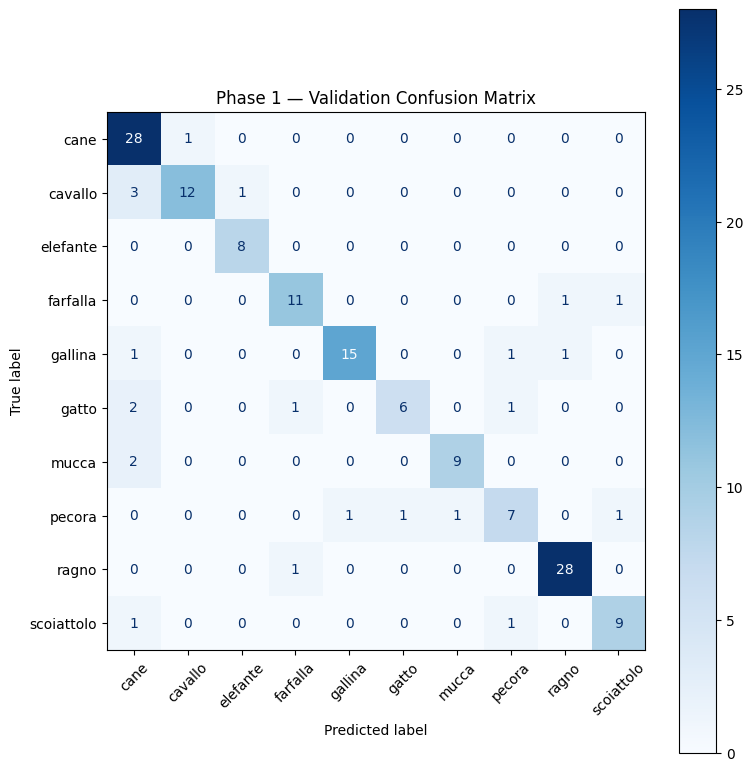

In [7]:
# CELL 7 — Phase 1 validation report and confusion matrix

def predict_validation(model, loader):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for images, targets in loader:
            logits = model(images.to(DEVICE, non_blocking=True))
            preds = logits.argmax(1).cpu().numpy()
            ys.extend(targets.numpy())
            ps.extend(preds)
    return np.array(ys), np.array(ps)

y1, p1 = predict_validation(phase1_model, val_loader)
acc1 = accuracy_score(y1, p1)
precision1, recall1, f1_1, _ = precision_recall_fscore_support(
    y1, p1, average="macro", zero_division=0
)

print("PHASE 1 VALIDATION")
print("Accuracy :", round(acc1, 4))
print("Precision:", round(precision1, 4))
print("Recall   :", round(recall1, 4))
print("Macro F1 :", round(f1_1, 4))
print("\nClassification report:")
print(classification_report(y1, p1, target_names=CLASS_NAMES, zero_division=0))

fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(
    y1, p1, display_labels=CLASS_NAMES, xticks_rotation=45, cmap="Blues", ax=ax
)
ax.set_title("Phase 1 — Validation Confusion Matrix")
plt.tight_layout()
plt.show()

## Phase 2 — SimCLR self-supervised learning on the unlabeled dataset

The unlabeled images are used **without labels**. SimCLR learns a useful visual representation by making two augmented views of the same image similar while separating different images. The resulting ResNet encoder is then transferred to the supervised animal classifier.

In [8]:
# CELL 8 — SimCLR dataset and strong augmentations

simclr_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.20, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([
        transforms.ColorJitter(0.8, 0.8, 0.8, 0.2)
    ], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=23, sigma=(0.1, 2.0))
    ], p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class SimCLRDataset(Dataset):
    def __init__(self, image_paths, transform):
        self.image_paths = list(image_paths)
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        with Image.open(self.image_paths[idx]) as im:
            image = im.convert("RGB")
        return self.transform(image), self.transform(image)

simclr_dataset = SimCLRDataset(unlabeled_files, simclr_transform)

simclr_loader_kwargs = dict(
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
if NUM_WORKERS > 0:
    simclr_loader_kwargs["persistent_workers"] = True

simclr_loader = DataLoader(simclr_dataset, **simclr_loader_kwargs)

print("Unlabeled images:", len(simclr_dataset))
print("SimCLR batches  :", len(simclr_loader))

Unlabeled images: 14800
SimCLR batches  : 462


In [9]:
# CELL 9 — SimCLR model and NT-Xent contrastive loss

class SimCLR(nn.Module):
    def __init__(self, projection_dim=128, pretrained=True):
        super().__init__()
        backbone = get_resnet18(pretrained=pretrained)
        feature_dim = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.encoder = backbone
        self.projector = nn.Sequential(
            nn.Linear(feature_dim, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, projection_dim),
        )

    def forward(self, x):
        h = self.encoder(x)
        z = F.normalize(self.projector(h), dim=1)
        return h, z


def nt_xent_loss(z1, z2, temperature=0.5):
    batch_size = z1.size(0)
    z = torch.cat([z1, z2], dim=0)
    similarity = torch.matmul(z, z.T) / temperature

    mask = torch.eye(2 * batch_size, device=z.device, dtype=torch.bool)
    similarity = similarity.masked_fill(mask, -1e9)

    positive_targets = torch.cat([
        torch.arange(batch_size, 2 * batch_size, device=z.device),
        torch.arange(0, batch_size, device=z.device),
    ])
    return F.cross_entropy(similarity, positive_targets)

simclr_model = SimCLR(
    projection_dim=SIMCLR_PROJECTION_DIM,
    pretrained=USE_IMAGENET_PRETRAINED,
).to(DEVICE)

optimizer_simclr = torch.optim.AdamW(
    simclr_model.parameters(),
    lr=SIMCLR_LR,
    weight_decay=SIMCLR_WEIGHT_DECAY,
)
scheduler_simclr = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_simclr, T_max=SIMCLR_EPOCHS
)

SIMCLR_PATH = OUTPUT_ROOT / "simclr_encoder.pt"

In [10]:
# CELL 10 — Run SimCLR pretraining and save the best encoder

best_simclr_loss = float("inf")
simclr_history = []

for epoch in range(1, SIMCLR_EPOCHS + 1):
    simclr_model.train()
    total_loss = 0.0
    total_n = 0
    start = time.time()

    for view1, view2 in simclr_loader:
        view1 = view1.to(DEVICE, non_blocking=True)
        view2 = view2.to(DEVICE, non_blocking=True)

        optimizer_simclr.zero_grad(set_to_none=True)
        _, z1 = simclr_model(view1)
        _, z2 = simclr_model(view2)
        loss = nt_xent_loss(z1, z2, SIMCLR_TEMPERATURE)
        loss.backward()
        optimizer_simclr.step()

        total_loss += loss.item() * view1.size(0)
        total_n += view1.size(0)

    epoch_loss = total_loss / max(total_n, 1)
    scheduler_simclr.step()
    simclr_history.append({"epoch": epoch, "simclr_loss": epoch_loss})

    print(
        f"SimCLR Epoch [{epoch:02d}/{SIMCLR_EPOCHS}] | "
        f"Loss: {epoch_loss:.4f} | Time: {time.time()-start:.1f}s"
    )

    if epoch_loss < best_simclr_loss:
        best_simclr_loss = epoch_loss
        torch.save({
            "encoder_state_dict": simclr_model.encoder.state_dict(),
            "class_names": CLASS_NAMES,
            "img_size": IMG_SIZE,
            "imagenet_mean": IMAGENET_MEAN,
            "imagenet_std": IMAGENET_STD,
            "best_simclr_loss": best_simclr_loss,
            "phase": "simclr_pretraining",
        }, SIMCLR_PATH)
        print(f"  ✓ Saved best SimCLR encoder: {best_simclr_loss:.4f}")

pd.DataFrame(simclr_history).to_csv(OUTPUT_ROOT / "simclr_training_history.csv", index=False)
print("\nBest SimCLR loss:", round(best_simclr_loss, 4))
print("Saved encoder:", SIMCLR_PATH.resolve())

SimCLR Epoch [01/10] | Loss: 2.7161 | Time: 533.7s
  ✓ Saved best SimCLR encoder: 2.7161
SimCLR Epoch [02/10] | Loss: 2.6067 | Time: 442.1s
  ✓ Saved best SimCLR encoder: 2.6067
SimCLR Epoch [03/10] | Loss: 2.5749 | Time: 372.0s
  ✓ Saved best SimCLR encoder: 2.5749
SimCLR Epoch [04/10] | Loss: 2.5572 | Time: 320.6s
  ✓ Saved best SimCLR encoder: 2.5572
SimCLR Epoch [05/10] | Loss: 2.5284 | Time: 302.5s
  ✓ Saved best SimCLR encoder: 2.5284


KeyboardInterrupt: 

## Phase 2 — Transfer the SimCLR encoder and fine-tune the classifier

In [11]:
# CELL 11 — Build Phase 2 classifier and load the saved SimCLR encoder

class Phase2Classifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        backbone = get_resnet18(pretrained=False)
        feature_dim = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.encoder = backbone
        self.classifier = nn.Linear(feature_dim, num_classes)

    def forward(self, x):
        features = self.encoder(x)
        return self.classifier(features)

phase2_model = Phase2Classifier(NUM_CLASSES).to(DEVICE)

simclr_checkpoint = torch.load(SIMCLR_PATH, map_location=DEVICE)
phase2_model.encoder.load_state_dict(simclr_checkpoint["encoder_state_dict"])
print("✓ SimCLR encoder loaded into Phase 2 classifier")

criterion2 = nn.CrossEntropyLoss(weight=class_weights)
optimizer2 = torch.optim.AdamW(
    phase2_model.parameters(),
    lr=PHASE2_LR,
    weight_decay=PHASE2_WEIGHT_DECAY,
)
scheduler2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer2, mode="max", factor=0.5, patience=2
)

PHASE2_PATH = OUTPUT_ROOT / "best_phase2_model.pt"

✓ SimCLR encoder loaded into Phase 2 classifier


In [12]:
# CELL 12 — Fine-tune Phase 2 classifier and save best model

phase2_history = []
best_phase2_acc = -1.0
best_phase2_state = None
bad_epochs = 0

for epoch in range(1, PHASE2_EPOCHS + 1):
    start = time.time()
    train_loss, train_acc = run_epoch(phase2_model, train_loader, criterion2, optimizer2)
    val_loss, val_acc = run_epoch(phase2_model, val_loader, criterion2)
    scheduler2.step(val_acc)

    phase2_history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "val_loss": val_loss,
        "val_accuracy": val_acc,
        "lr": optimizer2.param_groups[0]["lr"],
    })

    print(
        f"Epoch [{epoch:02d}/{PHASE2_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
        f"Time: {time.time()-start:.1f}s"
    )

    if val_acc > best_phase2_acc:
        best_phase2_acc = val_acc
        best_phase2_state = copy.deepcopy(phase2_model.state_dict())
        save_checkpoint(
            PHASE2_PATH,
            phase2_model,
            optimizer2,
            scheduler2,
            phase="phase2",
            best_val_accuracy=best_phase2_acc,
            simclr_encoder=SIMCLR_PATH.name,
        )
        bad_epochs = 0
        print(f"  ✓ Saved best Phase 2 model: {best_phase2_acc:.4f}")
    else:
        bad_epochs += 1

    if bad_epochs >= PHASE2_PATIENCE:
        print("Early stopping Phase 2.")
        break

phase2_model.load_state_dict(best_phase2_state)
pd.DataFrame(phase2_history).to_csv(OUTPUT_ROOT / "phase2_training_history.csv", index=False)

print("\nBest Phase 2 validation accuracy:", round(best_phase2_acc, 4))
print("Saved model:", PHASE2_PATH.resolve())

Epoch [01/20] | Train Loss: 1.7996 | Train Acc: 0.3804 | Val Loss: 1.5883 | Val Acc: 0.3333 | Time: 4.7s
  ✓ Saved best Phase 2 model: 0.3333
Epoch [02/20] | Train Loss: 1.1206 | Train Acc: 0.5730 | Val Loss: 1.3384 | Val Acc: 0.4551 | Time: 3.8s
  ✓ Saved best Phase 2 model: 0.4551
Epoch [03/20] | Train Loss: 0.7127 | Train Acc: 0.7014 | Val Loss: 1.1488 | Val Acc: 0.5128 | Time: 3.5s
  ✓ Saved best Phase 2 model: 0.5128
Epoch [04/20] | Train Loss: 0.5358 | Train Acc: 0.8058 | Val Loss: 1.0240 | Val Acc: 0.5833 | Time: 3.5s
  ✓ Saved best Phase 2 model: 0.5833
Epoch [05/20] | Train Loss: 0.4639 | Train Acc: 0.7978 | Val Loss: 0.9583 | Val Acc: 0.6667 | Time: 3.6s
  ✓ Saved best Phase 2 model: 0.6667
Epoch [06/20] | Train Loss: 0.3503 | Train Acc: 0.8684 | Val Loss: 0.8942 | Val Acc: 0.6859 | Time: 3.6s
  ✓ Saved best Phase 2 model: 0.6859
Epoch [07/20] | Train Loss: 0.2313 | Train Acc: 0.9310 | Val Loss: 0.8773 | Val Acc: 0.7115 | Time: 3.5s
  ✓ Saved best Phase 2 model: 0.7115
Epoch 

PHASE 2 VALIDATION
Accuracy : 0.8077
Precision: 0.7994
Recall   : 0.7879
Macro F1 : 0.7904

Classification report:
              precision    recall  f1-score   support

        cane       0.78      0.86      0.82        29
     cavallo       0.82      0.88      0.85        16
    elefante       1.00      1.00      1.00         8
    farfalla       0.75      0.92      0.83        13
     gallina       0.76      0.72      0.74        18
       gatto       0.75      0.60      0.67        10
       mucca       0.58      0.64      0.61        11
      pecora       0.78      0.64      0.70        11
       ragno       0.96      0.90      0.93        29
  scoiattolo       0.80      0.73      0.76        11

    accuracy                           0.81       156
   macro avg       0.80      0.79      0.79       156
weighted avg       0.81      0.81      0.81       156



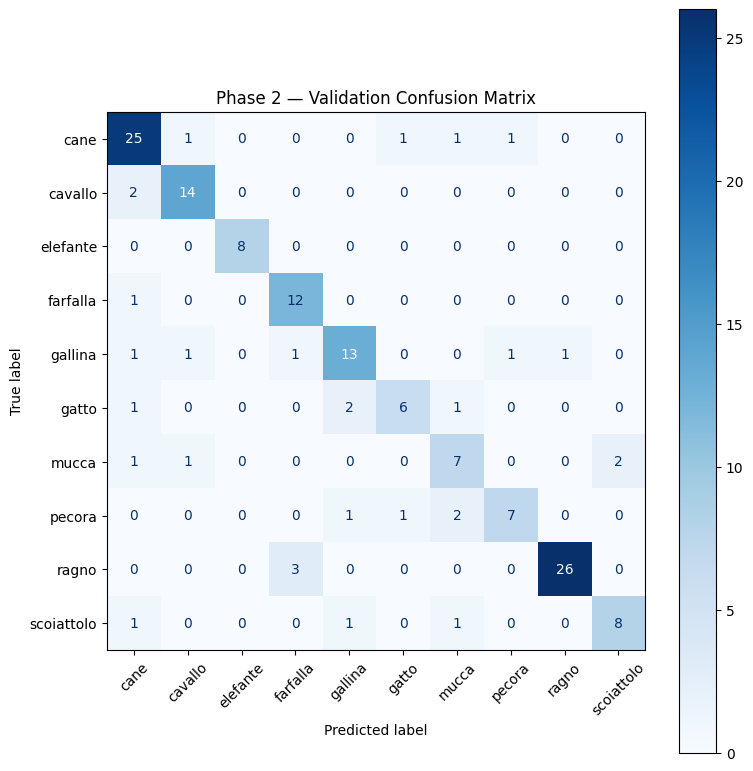

,phase,validation_accuracy,macro_f1
0,Phase 1 - Supervised ResNet-18,0.852564,0.834278
1,Phase 2 - SimCLR + Fine-tuning,0.807692,0.790444


In [13]:
# CELL 13 — Phase 2 validation report and Phase 1 vs Phase 2 comparison

y2, p2 = predict_validation(phase2_model, val_loader)
acc2 = accuracy_score(y2, p2)
precision2, recall2, f1_2, _ = precision_recall_fscore_support(
    y2, p2, average="macro", zero_division=0
)

print("PHASE 2 VALIDATION")
print("Accuracy :", round(acc2, 4))
print("Precision:", round(precision2, 4))
print("Recall   :", round(recall2, 4))
print("Macro F1 :", round(f1_2, 4))
print("\nClassification report:")
print(classification_report(y2, p2, target_names=CLASS_NAMES, zero_division=0))

fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(
    y2, p2, display_labels=CLASS_NAMES, xticks_rotation=45, cmap="Blues", ax=ax
)
ax.set_title("Phase 2 — Validation Confusion Matrix")
plt.tight_layout()
plt.show()

comparison_df = pd.DataFrame([
    {
        "phase": "Phase 1 - Supervised ResNet-18",
        "validation_accuracy": acc1,
        "macro_f1": f1_1,
    },
    {
        "phase": "Phase 2 - SimCLR + Fine-tuning",
        "validation_accuracy": acc2,
        "macro_f1": f1_2,
    },
])

display(comparison_df)
comparison_df.to_csv(OUTPUT_ROOT / "phase_comparison.csv", index=False)

## Final inference — run this section only when the separate test set is supplied

The hidden test images are **not required for training**. When you receive them, put the images in `test_data/images` (or change `TEST_IMAGE_ROOT` in Cell 1), then run the inference cells below.

Both phases produce separate CSV files because the submission checklist requires:
- `phase1_predictions.csv`
- `phase2_predictions.csv`

In [14]:
# ============================================================
# TEST CELL — FIND TEST IMAGES AND VERIFY THE PATH
# ============================================================

from pathlib import Path

# ------------------------------------------------------------
# CHANGE ONLY THIS PATH
# ------------------------------------------------------------

TEST_IMAGE_ROOT = Path(
    r"C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-Test\HV-AI-2025-Test\test_images"
)

# ------------------------------------------------------------
# CHECK PATH
# ------------------------------------------------------------

print("=" * 70)
print("TEST DATASET PATH CHECK")
print("=" * 70)

print("\nPath:")
print(TEST_IMAGE_ROOT)

print("\nExists:")
print(TEST_IMAGE_ROOT.exists())

print("\nIs directory:")
print(TEST_IMAGE_ROOT.is_dir())

# ------------------------------------------------------------
# FIND IMAGES
# ------------------------------------------------------------

if TEST_IMAGE_ROOT.exists() and TEST_IMAGE_ROOT.is_dir():

    extensions = {
        ".jpg",
        ".jpeg",
        ".png",
        ".webp",
        ".JPG",
        ".JPEG",
        ".PNG",
        ".WEBP"
    }

    test_files = sorted([
        p for p in TEST_IMAGE_ROOT.rglob("*")
        if p.is_file() and p.suffix in extensions
    ])

    print("\nNumber of test images:", len(test_files))

    print("\nFirst 20 test images:")

    for i, p in enumerate(test_files[:20], 1):
        print(f"{i:02d}. {p}")

    # --------------------------------------------------------
    # CHECK SAMPLE IMAGE
    # --------------------------------------------------------

    if len(test_files) > 0:

        sample = test_files[0]

        print("\n" + "-" * 70)
        print("SAMPLE IMAGE CHECK")
        print("-" * 70)

        print("Sample image:")
        print(sample)

        print("\nExists:", sample.exists())
        print("Size:", sample.stat().st_size, "bytes")

        try:
            from PIL import Image

            img = Image.open(sample)

            print("Image format:", img.format)
            print("Image size:", img.size)
            print("Image mode:", img.mode)

            img.verify()

            print("✓ Image can be opened successfully.")

        except Exception as e:

            print("❌ Image could not be opened.")
            print("Error:", e)

    else:

        print("\n❌ No image files found.")

else:

    print("\n❌ TEST DIRECTORY DOES NOT EXIST.")
    print("\nCheck the path carefully.")

print("\n" + "=" * 70)
print("PATH TEST COMPLETE")
print("=" * 70)

TEST DATASET PATH CHECK

Path:
C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-Test\HV-AI-2025-Test\test_images

Exists:
True

Is directory:
True

Number of test images: 10477

First 20 test images:
01. C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-Test\HV-AI-2025-Test\test_images\0_1034.jpeg
02. C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-Test\HV-AI-2025-Test\test_images\0_1045.jpeg
03. C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-Test\HV-AI-2025-Test\test_images\0_1085.jpeg
04. C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-Test\HV-AI-2025-Test\test_images\0_110.jpeg
05. C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-Test\HV-AI-2025-Test\test_images\0_1104.jpeg
06. C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-Test\HV-AI-2025-Test\test_images\0_1115.jpeg
07. C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-Test\HV-AI-2025-Test\test_images\0_1124.jpeg
08. C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-Test\HV-AI-2025-Test\test_images\0_1184.jpeg
09. C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-Test

In [15]:
# CELL 14 — Discover the test set safely

test_files = list_images(TEST_IMAGE_ROOT)

if len(test_files) == 0:
    print("TEST SET NOT FOUND YET")
    print("Expected folder:", TEST_IMAGE_ROOT.resolve())
    print("No prediction CSV will be generated until the test images are supplied.")
else:
    print("Test images found:", len(test_files))
    print("Example files:")
    for p in test_files[:10]:
        print(" ", p)

Test images found: 10477
Example files:
  C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-Test\HV-AI-2025-Test\test_images\0_1034.jpeg
  C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-Test\HV-AI-2025-Test\test_images\0_1045.jpeg
  C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-Test\HV-AI-2025-Test\test_images\0_1085.jpeg
  C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-Test\HV-AI-2025-Test\test_images\0_110.jpeg
  C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-Test\HV-AI-2025-Test\test_images\0_1104.jpeg
  C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-Test\HV-AI-2025-Test\test_images\0_1115.jpeg
  C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-Test\HV-AI-2025-Test\test_images\0_1124.jpeg
  C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-Test\HV-AI-2025-Test\test_images\0_1184.jpeg
  C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-Test\HV-AI-2025-Test\test_images\0_1216.jpeg
  C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-Test\HV-AI-2025-Test\test_images\0_1218.jpeg


In [16]:
# CELL 15 — Test dataset and inference utilities

class TestImageDataset(Dataset):
    def __init__(self, paths, transform):
        self.paths = list(paths)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        with Image.open(path) as im:
            image = im.convert("RGB")
        return self.transform(image), str(path)


def build_test_loader(paths):
    dataset = TestImageDataset(paths, eval_transform)
    kwargs = dict(
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )
    if NUM_WORKERS > 0:
        kwargs["persistent_workers"] = True
    return DataLoader(dataset, **kwargs)


def predict_test(model, paths):
    loader = build_test_loader(paths)
    model.eval()
    predicted_labels = []
    returned_paths = []

    with torch.no_grad():
        for images, batch_paths in loader:
            logits = model(images.to(DEVICE, non_blocking=True))
            pred_indices = logits.argmax(dim=1).cpu().tolist()
            predicted_labels.extend(idx_to_label[i] for i in pred_indices)
            returned_paths.extend(batch_paths)

    return returned_paths, predicted_labels


def make_submission(model, paths, output_path):
    actual_paths, predicted_labels = predict_test(model, paths)

    # The evaluation server expects relative paths such as test_data/images/xx.jpg.
    relative_paths = []
    for p in actual_paths:
        p = Path(p)
        try:
            rel = p.relative_to(DATA_ROOT)
            relative_paths.append(rel.as_posix())
        except ValueError:
            relative_paths.append(p.as_posix())

    submission = pd.DataFrame({
        "path": relative_paths,
        "predicted_label": predicted_labels,
    })
    submission.to_csv(output_path, index=False)
    return submission

print("Inference utilities ready.")

Inference utilities ready.


In [17]:
# CELL 16 — Generate Phase 1 and Phase 2 prediction CSVs

if len(test_files) == 0:
    print("Skipping inference: test set is not present yet.")
else:
    phase1_csv = OUTPUT_ROOT / "phase1_predictions.csv"
    phase2_csv = OUTPUT_ROOT / "phase2_predictions.csv"

    phase1_submission = make_submission(phase1_model, test_files, phase1_csv)
    phase2_submission = make_submission(phase2_model, test_files, phase2_csv)

    print("✓ Phase 1 CSV:", phase1_csv.resolve())
    print("✓ Phase 2 CSV:", phase2_csv.resolve())

    print("\nPhase 1 preview:")
    display(phase1_submission.head())
    print("Phase 2 preview:")
    display(phase2_submission.head())

✓ Phase 1 CSV: C:\Users\srima\Desktop\HyperVerge\hv_ai_outputs\phase1_predictions.csv
✓ Phase 2 CSV: C:\Users\srima\Desktop\HyperVerge\hv_ai_outputs\phase2_predictions.csv

Phase 1 preview:


,path,predicted_label
0,C:/Users/srima/Desktop/HyperVerge/HV-AI-2025-T...,ragno
1,C:/Users/srima/Desktop/HyperVerge/HV-AI-2025-T...,gatto
2,C:/Users/srima/Desktop/HyperVerge/HV-AI-2025-T...,gatto
3,C:/Users/srima/Desktop/HyperVerge/HV-AI-2025-T...,ragno
4,C:/Users/srima/Desktop/HyperVerge/HV-AI-2025-T...,gatto


Phase 2 preview:


,path,predicted_label
0,C:/Users/srima/Desktop/HyperVerge/HV-AI-2025-T...,gatto
1,C:/Users/srima/Desktop/HyperVerge/HV-AI-2025-T...,gatto
2,C:/Users/srima/Desktop/HyperVerge/HV-AI-2025-T...,gatto
3,C:/Users/srima/Desktop/HyperVerge/HV-AI-2025-T...,farfalla
4,C:/Users/srima/Desktop/HyperVerge/HV-AI-2025-T...,gatto


In [18]:
# CELL 17 — Strict final CSV verification

def verify_submission(csv_path, expected_rows):
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(csv_path)

    df = pd.read_csv(csv_path)
    assert list(df.columns) == ["path", "predicted_label"], list(df.columns)
    assert len(df) == expected_rows, (len(df), expected_rows)
    assert df["path"].notna().all()
    assert df["predicted_label"].notna().all()
    assert not df["path"].duplicated().any(), "Duplicate test paths found"

    invalid = sorted(set(df["predicted_label"]) - set(CLASS_NAMES))
    assert not invalid, f"Invalid predicted classes: {invalid}"
    return df

if len(test_files) == 0:
    print("No test set yet — verification will be run after test inference.")
else:
    verify_submission(OUTPUT_ROOT / "phase1_predictions.csv", len(test_files))
    verify_submission(OUTPUT_ROOT / "phase2_predictions.csv", len(test_files))
    print("✓ Both prediction CSVs passed verification.")

✓ Both prediction CSVs passed verification.


## Saved-model verification and final checklist

In [19]:
# CELL 18 — Confirm all reusable models and training artifacts are saved

expected_artifacts = [
    OUTPUT_ROOT / "best_phase1_model.pt",
    OUTPUT_ROOT / "simclr_encoder.pt",
    OUTPUT_ROOT / "best_phase2_model.pt",
    OUTPUT_ROOT / "phase1_training_history.csv",
    OUTPUT_ROOT / "simclr_training_history.csv",
    OUTPUT_ROOT / "phase2_training_history.csv",
    OUTPUT_ROOT / "phase_comparison.csv",
]

for artifact in expected_artifacts:
    print(("✓ " if artifact.exists() else "✗ ") + str(artifact.resolve()))

print("\nThese saved .pt files contain the model weights and class mapping, so")
print("the test set can be supplied later without retraining from scratch.")

✓ C:\Users\srima\Desktop\HyperVerge\hv_ai_outputs\best_phase1_model.pt
✓ C:\Users\srima\Desktop\HyperVerge\hv_ai_outputs\simclr_encoder.pt
✓ C:\Users\srima\Desktop\HyperVerge\hv_ai_outputs\best_phase2_model.pt
✓ C:\Users\srima\Desktop\HyperVerge\hv_ai_outputs\phase1_training_history.csv
✗ C:\Users\srima\Desktop\HyperVerge\hv_ai_outputs\simclr_training_history.csv
✓ C:\Users\srima\Desktop\HyperVerge\hv_ai_outputs\phase2_training_history.csv
✓ C:\Users\srima\Desktop\HyperVerge\hv_ai_outputs\phase_comparison.csv

These saved .pt files contain the model weights and class mapping, so
the test set can be supplied later without retraining from scratch.


In [20]:
# CELL 19 — Final project summary

print("=" * 72)
print("HV-AI-2025 — FINAL SUMMARY")
print("=" * 72)
print("Dataset root      :", DATA_ROOT.resolve())
print("Labeled rows used  :", len(matched_df))
print("Train rows         :", len(train_df))
print("Validation rows    :", len(val_df))
print("Unlabeled images   :", len(unlabeled_files))
print("Test images        :", len(test_files))
print("Classes            :", CLASS_NAMES)
print()
print("PHASE 1")
print("  Validation accuracy:", round(acc1, 4))
print("  Macro F1           :", round(f1_1, 4))
print("  Model              :", (OUTPUT_ROOT / "best_phase1_model.pt").resolve())
print()
print("PHASE 2")
print("  Validation accuracy:", round(acc2, 4))
print("  Macro F1           :", round(f1_2, 4))
print("  SimCLR encoder     :", (OUTPUT_ROOT / "simclr_encoder.pt").resolve())
print("  Model              :", (OUTPUT_ROOT / "best_phase2_model.pt").resolve())
print()

if test_files:
    print("SUBMISSION FILES")
    print("  1.", (OUTPUT_ROOT / "phase1_predictions.csv").resolve())
    print("  2.", (OUTPUT_ROOT / "phase2_predictions.csv").resolve())
else:
    print("TEST SET STATUS")
    print("  The separate test set has not been supplied yet.")
    print("  Once supplied, run Cells 14–17 to generate both CSVs.")

HV-AI-2025 — FINAL SUMMARY
Dataset root      : C:\Users\srima\Desktop\HyperVerge\HV-AI-2025\HV-AI-2025
Labeled rows used  : 779
Train rows         : 623
Validation rows    : 156
Unlabeled images   : 14800
Test images        : 10477
Classes            : ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']

PHASE 1
  Validation accuracy: 0.8526
  Macro F1           : 0.8343
  Model              : C:\Users\srima\Desktop\HyperVerge\hv_ai_outputs\best_phase1_model.pt

PHASE 2
  Validation accuracy: 0.8077
  Macro F1           : 0.7904
  SimCLR encoder     : C:\Users\srima\Desktop\HyperVerge\hv_ai_outputs\simclr_encoder.pt
  Model              : C:\Users\srima\Desktop\HyperVerge\hv_ai_outputs\best_phase2_model.pt

SUBMISSION FILES
  1. C:\Users\srima\Desktop\HyperVerge\hv_ai_outputs\phase1_predictions.csv
  2. C:\Users\srima\Desktop\HyperVerge\hv_ai_outputs\phase2_predictions.csv


## Later: reload saved models without retraining

When the test set arrives in a new session, you can load the saved `.pt` files and run inference. The next cell is a template and does not run until the test set exists.

In [21]:
# CELL 20 — Reload saved Phase 1 / Phase 2 models for future test inference
# Run this in a fresh session AFTER running Cells 1–5.
# The two small architecture definitions below make this reload cell independent
# of the training cells.

class Phase2ClassifierReload(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        backbone = get_resnet18(pretrained=False)
        feature_dim = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.encoder = backbone
        self.classifier = nn.Linear(feature_dim, num_classes)

    def forward(self, x):
        return self.classifier(self.encoder(x))

if (OUTPUT_ROOT / "best_phase1_model.pt").exists() and (OUTPUT_ROOT / "best_phase2_model.pt").exists():
    phase1_saved = torch.load(OUTPUT_ROOT / "best_phase1_model.pt", map_location=DEVICE)
    phase2_saved = torch.load(OUTPUT_ROOT / "best_phase2_model.pt", map_location=DEVICE)

    phase1_reload = build_classifier(NUM_CLASSES, pretrained=False).to(DEVICE)
    phase1_reload.load_state_dict(phase1_saved["model_state_dict"])
    phase1_reload.eval()

    phase2_reload = Phase2ClassifierReload(NUM_CLASSES).to(DEVICE)
    phase2_reload.load_state_dict(phase2_saved["model_state_dict"])
    phase2_reload.eval()

    print("✓ Saved Phase 1 model reloaded.")
    print("✓ Saved Phase 2 model reloaded.")
    print("When test_files is available, call:")
    print("  make_submission(phase1_reload, test_files, OUTPUT_ROOT / 'phase1_predictions.csv')")
    print("  make_submission(phase2_reload, test_files, OUTPUT_ROOT / 'phase2_predictions.csv')")
else:
    print("Saved model files are not present yet. Complete training first.")

✓ Saved Phase 1 model reloaded.
✓ Saved Phase 2 model reloaded.
When test_files is available, call:
  make_submission(phase1_reload, test_files, OUTPUT_ROOT / 'phase1_predictions.csv')
  make_submission(phase2_reload, test_files, OUTPUT_ROOT / 'phase2_predictions.csv')


In [23]:
# ============================================================
# CELL 21 — LOAD / CHECK TEST IMAGES
# ============================================================

# Your test image folder
TEST_IMAGE_ROOT = Path(
    r"C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-Test\HV-AI-2025-Test\test_images"
)

test_files = list_images(TEST_IMAGE_ROOT)

print("=" * 60)
print("TEST SET")
print("=" * 60)

print("Test folder:", TEST_IMAGE_ROOT)
print("Images found:", len(test_files))

print("\nFirst 10 images:")
for p in test_files[:10]:
    print(p)

TEST SET
Test folder: C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-Test\HV-AI-2025-Test\test_images
Images found: 10477

First 10 images:
C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-Test\HV-AI-2025-Test\test_images\0_1034.jpeg
C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-Test\HV-AI-2025-Test\test_images\0_1045.jpeg
C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-Test\HV-AI-2025-Test\test_images\0_1085.jpeg
C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-Test\HV-AI-2025-Test\test_images\0_110.jpeg
C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-Test\HV-AI-2025-Test\test_images\0_1104.jpeg
C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-Test\HV-AI-2025-Test\test_images\0_1115.jpeg
C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-Test\HV-AI-2025-Test\test_images\0_1124.jpeg
C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-Test\HV-AI-2025-Test\test_images\0_1184.jpeg
C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-Test\HV-AI-2025-Test\test_images\0_1216.jpeg
C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-Test\HV-

In [29]:
# ============================================================
# FINAL TEST INFERENCE — PHASE 1 + PHASE 2
# ============================================================
#
# Loads:
#   best_phase1_model.pt
#   best_phase2_model.pt
#
# Predicts:
#   Entire test dataset
#
# Saves:
#   phase1_test_predictions.csv
#   phase2_test_predictions.csv
#   test_predictions_both_models.csv
#
# Also calculates accuracy IF test labels are available.
# ============================================================

import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet18

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# 1. CONFIGURATION
# ============================================================

TEST_DIR = r"C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-Test\HV-AI-2025-Test\test_images"

OUTPUT_DIR = r"C:\Users\srima\Desktop\HyperVerge\hv_ai_outputs"

PHASE1_MODEL_PATH = os.path.join(
    OUTPUT_DIR,
    "best_phase1_model.pt"
)

PHASE2_MODEL_PATH = os.path.join(
    OUTPUT_DIR,
    "best_phase2_model.pt"
)

PHASE1_CSV = os.path.join(
    OUTPUT_DIR,
    "phase1_test_predictions.csv"
)

PHASE2_CSV = os.path.join(
    OUTPUT_DIR,
    "phase2_test_predictions.csv"
)

COMBINED_CSV = os.path.join(
    OUTPUT_DIR,
    "test_predictions_both_models.csv"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

BATCH_SIZE = 32
IMG_SIZE = 224

print("=" * 70)
print("HYPERVERGE — FINAL TEST INFERENCE")
print("=" * 70)

print("Device:", DEVICE)
print("Test directory:", TEST_DIR)
print("Phase 1 model:", PHASE1_MODEL_PATH)
print("Phase 2 model:", PHASE2_MODEL_PATH)


# ============================================================
# 2. CHECK PATHS
# ============================================================

if not os.path.isdir(TEST_DIR):
    raise FileNotFoundError(
        f"\nTest directory not found:\n{TEST_DIR}"
    )

if not os.path.isfile(PHASE1_MODEL_PATH):
    raise FileNotFoundError(
        f"\nPhase 1 model not found:\n{PHASE1_MODEL_PATH}"
    )

if not os.path.isfile(PHASE2_MODEL_PATH):
    raise FileNotFoundError(
        f"\nPhase 2 model not found:\n{PHASE2_MODEL_PATH}"
    )

print("\n✓ Test directory found")
print("✓ Phase 1 model found")
print("✓ Phase 2 model found")


# ============================================================
# 3. DISCOVER TEST IMAGES
# ============================================================

extensions = (
    "*.jpg",
    "*.jpeg",
    "*.png",
    "*.webp",
    "*.JPG",
    "*.JPEG",
    "*.PNG",
    "*.WEBP"
)

test_files = []

for ext in extensions:
    test_files.extend(
        glob.glob(
            os.path.join(TEST_DIR, ext)
        )
    )

test_files = sorted(test_files)

if len(test_files) == 0:
    raise RuntimeError(
        "No test images found in:\n" + TEST_DIR
    )

print("\nNumber of test images:", len(test_files))

print("\nFirst 10 images:")

for p in test_files[:10]:
    print(" ", os.path.basename(p))


# ============================================================
# 4. LOAD CLASS NAMES
# ============================================================
#
# IMPORTANT:
# The labeled training CSV should contain the actual labels.
#
# We first try to locate labeled_data.csv.
# ============================================================

TRAIN_CSV_CANDIDATES = [
    r"C:\Users\srima\Desktop\HyperVerge\HV-AI-2025\HV-AI-2025\labeled_data\labeled_data.csv",
    r"C:\Users\srima\Desktop\HyperVerge\HV-AI-2025\labeled_data\labeled_data.csv"
]

TRAIN_CSV = None

for candidate in TRAIN_CSV_CANDIDATES:
    if os.path.isfile(candidate):
        TRAIN_CSV = candidate
        break


if TRAIN_CSV is None:

    print("\n⚠ labeled_data.csv was not found automatically.")

    # --------------------------------------------------------
    # FALLBACK:
    # Use the class order saved in the model checkpoint.
    # --------------------------------------------------------

    phase1_temp = torch.load(
        PHASE1_MODEL_PATH,
        map_location="cpu"
    )

    if isinstance(phase1_temp, dict):

        if "class_names" in phase1_temp:
            CLASS_NAMES = list(
                phase1_temp["class_names"]
            )

        elif "classes" in phase1_temp:
            CLASS_NAMES = list(
                phase1_temp["classes"]
            )

        else:
            raise RuntimeError(
                "\nCould not determine class names.\n"
                "Please set CLASS_NAMES manually using "
                "the exact class order used during training."
            )

    else:
        raise RuntimeError(
            "Unable to determine class names."
        )

else:

    print("\nTraining CSV found:")
    print(TRAIN_CSV)

    train_df = pd.read_csv(TRAIN_CSV)

    print("\nTraining CSV columns:")
    print(list(train_df.columns))

    # --------------------------------------------------------
    # Try common label column names
    # --------------------------------------------------------

    label_column = None

    for col in [
        "label",
        "label_id",
        "class",
        "class_name",
        "category",
        "target"
    ]:
        if col in train_df.columns:
            label_column = col
            break

    if label_column is None:
        raise RuntimeError(
            "\nCould not identify label column in training CSV.\n"
            f"Columns found: {list(train_df.columns)}"
        )

    CLASS_NAMES = sorted(
        train_df[label_column]
        .astype(str)
        .unique()
        .tolist()
    )

print("\nClass names:")

for i, name in enumerate(CLASS_NAMES):
    print(f"  {i}: {name}")

NUM_CLASSES = len(CLASS_NAMES)

print("\nNumber of classes:", NUM_CLASSES)


# ============================================================
# 5. IMAGE TRANSFORM
# ============================================================

test_transform = transforms.Compose([
    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ============================================================
# 6. TEST DATASET
# ============================================================

class TestImageDataset(Dataset):

    def __init__(
        self,
        image_paths,
        transform=None
    ):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):

        path = self.image_paths[idx]

        image = Image.open(path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, path


test_dataset = TestImageDataset(
    test_files,
    transform=test_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("\n✓ Test DataLoader ready")


# ============================================================
# 7. PHASE 1 MODEL ARCHITECTURE
# ============================================================

def create_phase1_model(num_classes):

    model = resnet18(weights=None)

    feature_dim = model.fc.in_features

    model.fc = nn.Linear(
        feature_dim,
        num_classes
    )

    return model


# ============================================================
# 8. PHASE 2 MODEL ARCHITECTURE
# ============================================================
#
# THIS IS THE IMPORTANT FIX.
#
# Your Phase 2 checkpoint contains:
#
# encoder.conv1...
# encoder.layer1...
# classifier.weight
# classifier.bias
#
# Therefore we MUST recreate this exact wrapper.
# ============================================================

class Phase2Classifier(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        encoder = resnet18(
            weights=None
        )

        feature_dim = encoder.fc.in_features

        # Remove original ResNet classifier
        encoder.fc = nn.Identity()

        self.encoder = encoder

        # New classification head
        self.classifier = nn.Linear(
            feature_dim,
            num_classes
        )

    def forward(self, x):

        features = self.encoder(x)

        logits = self.classifier(features)

        return logits


# ============================================================
# 9. ROBUST CHECKPOINT LOADER
# ============================================================

def extract_state_dict(checkpoint):

    if isinstance(checkpoint, dict):

        possible_keys = [
            "model_state_dict",
            "state_dict",
            "model"
        ]

        for key in possible_keys:

            if key in checkpoint:

                value = checkpoint[key]

                if isinstance(value, dict):
                    return value

        # Sometimes checkpoint itself is state_dict
        if all(
            isinstance(v, torch.Tensor)
            for v in checkpoint.values()
        ):
            return checkpoint

    raise RuntimeError(
        "Could not extract model state_dict from checkpoint."
    )


# ============================================================
# 10. LOAD PHASE 1
# ============================================================

print("\n" + "=" * 70)
print("LOADING PHASE 1")
print("=" * 70)

phase1_checkpoint = torch.load(
    PHASE1_MODEL_PATH,
    map_location="cpu"
)

phase1_state = extract_state_dict(
    phase1_checkpoint
)

phase1_model = create_phase1_model(
    NUM_CLASSES
)

phase1_model.load_state_dict(
    phase1_state,
    strict=True
)

phase1_model = phase1_model.to(DEVICE)

phase1_model.eval()

print("✓ Phase 1 loaded successfully")


# ============================================================
# 11. LOAD PHASE 2
# ============================================================

print("\n" + "=" * 70)
print("LOADING PHASE 2")
print("=" * 70)

phase2_checkpoint = torch.load(
    PHASE2_MODEL_PATH,
    map_location="cpu"
)

phase2_state = extract_state_dict(
    phase2_checkpoint
)

phase2_model = Phase2Classifier(
    NUM_CLASSES
)

# THIS fixes your error:
#
# checkpoint:
# encoder.conv1...
# classifier...
#
# model:
# encoder.conv1...
# classifier...

phase2_model.load_state_dict(
    phase2_state,
    strict=True
)

phase2_model = phase2_model.to(DEVICE)

phase2_model.eval()

print("✓ Phase 2 loaded successfully")


# ============================================================
# 12. PREDICTION FUNCTION
# ============================================================

def predict_model(
    model,
    loader,
    model_name
):

    all_paths = []
    all_predictions = []
    all_confidences = []

    all_probabilities = []

    with torch.no_grad():

        for images, paths in loader:

            images = images.to(
                DEVICE,
                non_blocking=True
            )

            logits = model(images)

            probabilities = torch.softmax(
                logits,
                dim=1
            )

            confidence, predictions = torch.max(
                probabilities,
                dim=1
            )

            all_paths.extend(paths)

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_confidences.extend(
                confidence.cpu().numpy()
            )

            all_probabilities.extend(
                probabilities.cpu().numpy()
            )

    results = []

    for i in range(len(all_paths)):

        pred_id = int(
            all_predictions[i]
        )

        row = {
            "path": all_paths[i],
            "filename": os.path.basename(
                all_paths[i]
            ),
            "predicted_label_id": pred_id,
            "predicted_label": CLASS_NAMES[pred_id],
            "confidence": float(
                all_confidences[i]
            )
        }

        # Add probability for every class
        for class_id, class_name in enumerate(
            CLASS_NAMES
        ):

            row[
                f"prob_{class_name}"
            ] = float(
                all_probabilities[i][class_id]
            )

        results.append(row)

    df = pd.DataFrame(results)

    print(
        f"\n✓ {model_name} predictions completed"
    )

    return df


# ============================================================
# 13. RUN PHASE 1 PREDICTIONS
# ============================================================

print("\n" + "=" * 70)
print("PHASE 1 PREDICTION")
print("=" * 70)

phase1_results = predict_model(
    phase1_model,
    test_loader,
    "Phase 1"
)

phase1_results.to_csv(
    PHASE1_CSV,
    index=False
)

print(
    "\nSaved:",
    PHASE1_CSV
)


# ============================================================
# 14. RUN PHASE 2 PREDICTIONS
# ============================================================

print("\n" + "=" * 70)
print("PHASE 2 PREDICTION")
print("=" * 70)

phase2_results = predict_model(
    phase2_model,
    test_loader,
    "Phase 2"
)

phase2_results.to_csv(
    PHASE2_CSV,
    index=False
)

print(
    "\nSaved:",
    PHASE2_CSV
)


# ============================================================
# 15. COMBINE BOTH RESULTS
# ============================================================

combined = pd.DataFrame({
    "path": phase1_results["path"],
    "filename": phase1_results["filename"],

    "phase1_prediction":
        phase1_results["predicted_label"],

    "phase1_confidence":
        phase1_results["confidence"],

    "phase2_prediction":
        phase2_results["predicted_label"],

    "phase2_confidence":
        phase2_results["confidence"]
})

combined["models_agree"] = (
    combined["phase1_prediction"]
    ==
    combined["phase2_prediction"]
)

combined.to_csv(
    COMBINED_CSV,
    index=False
)

print(
    "\n✓ Combined results saved:"
)

print(COMBINED_CSV)


# ============================================================
# 16. DISPLAY SAMPLE RESULTS
# ============================================================

print("\n" + "=" * 70)
print("FIRST 20 TEST PREDICTIONS")
print("=" * 70)

display(
    combined.head(20)
)


# ============================================================
# 17. MODEL AGREEMENT
# ============================================================

agreement = (
    combined["models_agree"]
    .mean()
)

print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

print(
    f"Total test images: {len(combined)}"
)

print(
    f"Phase 1 average confidence: "
    f"{combined['phase1_confidence'].mean():.4f}"
)

print(
    f"Phase 2 average confidence: "
    f"{combined['phase2_confidence'].mean():.4f}"
)

print(
    f"Phase 1 / Phase 2 agreement: "
    f"{agreement:.4f}"
)


# ============================================================
# 18. PREDICTION DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("PHASE 1 PREDICTION DISTRIBUTION")
print("=" * 70)

display(
    combined[
        "phase1_prediction"
    ].value_counts().to_frame(
        "count"
    )
)


print("\n" + "=" * 70)
print("PHASE 2 PREDICTION DISTRIBUTION")
print("=" * 70)

display(
    combined[
        "phase2_prediction"
    ].value_counts().to_frame(
        "count"
    )
)


# ============================================================
# 19. ACCURACY CHECK
# ============================================================
#
# VERY IMPORTANT:
#
# A test set containing only images does NOT provide accuracy.
#
# Accuracy requires:
#
#       actual_label
#             +
#       predicted_label
#
# If the organizers give a test-label CSV later, put its path
# below and this section will calculate the actual test accuracy.
# ============================================================

TEST_LABELS_CSV = None

# Example:
#
# TEST_LABELS_CSV = r"C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-Test\test_labels.csv"


if (
    TEST_LABELS_CSV is not None
    and os.path.isfile(TEST_LABELS_CSV)
):

    print("\n" + "=" * 70)
    print("TEST SET ACCURACY")
    print("=" * 70)

    labels_df = pd.read_csv(
        TEST_LABELS_CSV
    )

    print(
        "Label CSV columns:",
        list(labels_df.columns)
    )

    # --------------------------------------------------------
    # Find image/path column
    # --------------------------------------------------------

    path_col = None

    for col in [
        "path",
        "image_path",
        "filename",
        "image",
        "file"
    ]:

        if col in labels_df.columns:
            path_col = col
            break

    # --------------------------------------------------------
    # Find actual label column
    # --------------------------------------------------------

    actual_col = None

    for col in [
        "label",
        "label_id",
        "class",
        "class_name",
        "category",
        "target"
    ]:

        if col in labels_df.columns:
            actual_col = col
            break

    if path_col is None or actual_col is None:

        raise RuntimeError(
            "\nCould not identify path/label columns "
            "in test label CSV."
        )

    # --------------------------------------------------------
    # Normalize filenames
    # --------------------------------------------------------

    labels_df["filename"] = (
        labels_df[path_col]
        .astype(str)
        .apply(os.path.basename)
    )

    evaluation_df = combined.merge(
        labels_df[
            [
                "filename",
                actual_col
            ]
        ],
        on="filename",
        how="inner"
    )

    if len(evaluation_df) == 0:

        raise RuntimeError(
            "No test images matched the label CSV."
        )

    # --------------------------------------------------------
    # Convert actual labels to strings
    # --------------------------------------------------------

    evaluation_df["actual_label"] = (
        evaluation_df[actual_col]
        .astype(str)
    )

    evaluation_df["phase1_prediction"] = (
        evaluation_df[
            "phase1_prediction"
        ].astype(str)
    )

    evaluation_df["phase2_prediction"] = (
        evaluation_df[
            "phase2_prediction"
        ].astype(str)
    )

    # --------------------------------------------------------
    # ACCURACY
    # --------------------------------------------------------

    phase1_accuracy = accuracy_score(
        evaluation_df["actual_label"],
        evaluation_df["phase1_prediction"]
    )

    phase2_accuracy = accuracy_score(
        evaluation_df["actual_label"],
        evaluation_df["phase2_prediction"]
    )

    print(
        f"\nPhase 1 TEST ACCURACY: "
        f"{phase1_accuracy:.4f}"
    )

    print(
        f"Phase 2 TEST ACCURACY: "
        f"{phase2_accuracy:.4f}"
    )

    print(
        f"\nPhase 1 TEST ACCURACY: "
        f"{phase1_accuracy * 100:.2f}%"
    )

    print(
        f"Phase 2 TEST ACCURACY: "
        f"{phase2_accuracy * 100:.2f}%"
    )

    # --------------------------------------------------------
    # PHASE 1 REPORT
    # --------------------------------------------------------

    print("\n" + "=" * 70)
    print("PHASE 1 TEST CLASSIFICATION REPORT")
    print("=" * 70)

    print(
        classification_report(
            evaluation_df["actual_label"],
            evaluation_df["phase1_prediction"],
            zero_division=0
        )
    )

    # --------------------------------------------------------
    # PHASE 2 REPORT
    # --------------------------------------------------------

    print("\n" + "=" * 70)
    print("PHASE 2 TEST CLASSIFICATION REPORT")
    print("=" * 70)

    print(
        classification_report(
            evaluation_df["actual_label"],
            evaluation_df["phase2_prediction"],
            zero_division=0
        )
    )

    # --------------------------------------------------------
    # SAVE EVALUATION
    # --------------------------------------------------------

    evaluation_path = os.path.join(
        OUTPUT_DIR,
        "test_accuracy_results.csv"
    )

    evaluation_df.to_csv(
        evaluation_path,
        index=False
    )

    print(
        "\n✓ Evaluation results saved:"
    )

    print(evaluation_path)

else:

    print("\n" + "=" * 70)
    print("IMPORTANT — TEST ACCURACY")
    print("=" * 70)

    print(
        "\nThe test folder contains images, but no "
        "ground-truth labels were supplied to this code."
    )

    print(
        "\nTherefore TRUE TEST ACCURACY CANNOT be calculated "
        "from the images alone."
    )

    print(
        "\nThe following files have been generated instead:"
    )

    print(
        "  1.",
        PHASE1_CSV
    )

    print(
        "  2.",
        PHASE2_CSV
    )

    print(
        "  3.",
        COMBINED_CSV
    )

    print(
        "\nThese contain predictions + confidence scores "
        "for the complete test set."
    )


# ============================================================
# 20. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FINAL SUMMARY")
print("=" * 70)

print(
    f"Test images processed : {len(test_files)}"
)

print(
    "Phase 1 model        : ✓ loaded"
)

print(
    "Phase 2 model        : ✓ loaded"
)

print(
    "Phase 1 CSV           : ✓ saved"
)

print(
    "Phase 2 CSV           : ✓ saved"
)

print(
    "Combined CSV          : ✓ saved"
)

print("\nOutput directory:")
print(OUTPUT_DIR)

print("\nDONE.")

HYPERVERGE — FINAL TEST INFERENCE
Device: cuda
Test directory: C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-Test\HV-AI-2025-Test\test_images
Phase 1 model: C:\Users\srima\Desktop\HyperVerge\hv_ai_outputs\best_phase1_model.pt
Phase 2 model: C:\Users\srima\Desktop\HyperVerge\hv_ai_outputs\best_phase2_model.pt

✓ Test directory found
✓ Phase 1 model found
✓ Phase 2 model found

Number of test images: 20954

First 10 images:
  0_1034.jpeg
  0_1034.jpeg
  0_1045.jpeg
  0_1045.jpeg
  0_1085.jpeg
  0_1085.jpeg
  0_110.jpeg
  0_110.jpeg
  0_1104.jpeg
  0_1104.jpeg

Training CSV found:
C:\Users\srima\Desktop\HyperVerge\HV-AI-2025\HV-AI-2025\labeled_data\labeled_data.csv

Training CSV columns:
['img_name', 'label']

Class names:
  0: cane
  1: cavallo
  2: elefante
  3: farfalla
  4: gallina
  5: gatto
  6: mucca
  7: pecora
  8: ragno
  9: scoiattolo

Number of classes: 10

✓ Test DataLoader ready

LOADING PHASE 1
✓ Phase 1 loaded successfully

LOADING PHASE 2
✓ Phase 2 loaded successfully

PHA

,path,filename,phase1_prediction,phase1_confidence,phase2_prediction,phase2_confidence,models_agree
0,C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-T...,0_1034.jpeg,ragno,0.368836,gatto,0.772079,False
1,C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-T...,0_1034.jpeg,ragno,0.368836,gatto,0.772079,False
2,C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-T...,0_1045.jpeg,gatto,0.880041,gatto,0.987771,True
3,C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-T...,0_1045.jpeg,gatto,0.880041,gatto,0.987771,True
4,C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-T...,0_1085.jpeg,gatto,0.967058,gatto,0.993302,True
5,C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-T...,0_1085.jpeg,gatto,0.967058,gatto,0.993302,True
6,C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-T...,0_110.jpeg,ragno,0.680930,farfalla,0.524204,False
7,C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-T...,0_110.jpeg,ragno,0.680930,farfalla,0.524204,False
8,C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-T...,0_1104.jpeg,gatto,0.834579,gatto,0.847119,True
9,C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-T...,0_1104.jpeg,gatto,0.834579,gatto,0.847119,True



MODEL COMPARISON
Total test images: 20954
Phase 1 average confidence: 0.6612
Phase 2 average confidence: 0.7327
Phase 1 / Phase 2 agreement: 0.4057

PHASE 1 PREDICTION DISTRIBUTION


,count
phase1_prediction,
ragno,13820
gallina,2872
cane,1696
gatto,1186
farfalla,1152
scoiattolo,116
pecora,40
cavallo,38
elefante,20



PHASE 2 PREDICTION DISTRIBUTION


,count
phase2_prediction,
gallina,5868
ragno,4070
farfalla,3434
cane,2828
gatto,2038
scoiattolo,892
cavallo,878
elefante,552
mucca,296



IMPORTANT — TEST ACCURACY

The test folder contains images, but no ground-truth labels were supplied to this code.

Therefore TRUE TEST ACCURACY CANNOT be calculated from the images alone.

The following files have been generated instead:
  1. C:\Users\srima\Desktop\HyperVerge\hv_ai_outputs\phase1_test_predictions.csv
  2. C:\Users\srima\Desktop\HyperVerge\hv_ai_outputs\phase2_test_predictions.csv
  3. C:\Users\srima\Desktop\HyperVerge\hv_ai_outputs\test_predictions_both_models.csv

These contain predictions + confidence scores for the complete test set.

FINAL SUMMARY
Test images processed : 20954
Phase 1 model        : ✓ loaded
Phase 2 model        : ✓ loaded
Phase 1 CSV           : ✓ saved
Phase 2 CSV           : ✓ saved
Combined CSV          : ✓ saved

Output directory:
C:\Users\srima\Desktop\HyperVerge\hv_ai_outputs

DONE.
